# Indian Railways Analysis
**Author:** Utsav  
**Dataset:** Indian Railways Schedule Data  
**Source:** Kaggle — sripaadsrinivasan/indian-railways-dataset

## Objective
Analyze Indian Railways schedule data to find insights about:
1. Busiest stations in India
2. Trains with longest routes
3. Train type distribution
4. Premium train network
5. Multi-day journey analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load datasets
trains = pd.read_json('trains.json')
stations = pd.read_json('stations.json')
df = pd.read_json('schedules.json')

print("Datasets loaded successfully!")
print(f"Schedules: {df.shape[0]:,} rows, {df.shape[1]} columns")

Datasets loaded successfully!
Schedules: 417,080 rows, 8 columns


## EDA — Understanding the Data

### What each column means

| Column | Description | Example |
|---|---|---|
| `train_number` | Unique number assigned to each train by Indian Railways | 19269 |
| `train_name` | Full name of the train | Porbandar Muzaffarpur Express |
| `station_name` | Name of each station on the route | PORBANDAR |
| `station_code` | Short 2-5 letter code for the station | PBR |
| `arrival` | Time train arrives at this station | 14:30:00 |
| `departure` | Time train departs from this station | 14:35:00 |
| `day` | Journey day number for long distance trains | 1.0, 2.0, 3.0 |
| `id` | Unique row identifier | 309335 |

### Key observations from EDA
- **Arrival is None for first station** — train originates there, so no arrival time
- **Departure is None for last station** — train terminates there, so no departure time
- **Day column has 22,561 missing values** — these are local/short trains with no day tracking
- **trains.json and stations.json are GeoJSON format** — geographic data, not tabular
- **schedules.json is our main dataset** — 417,080 records covering all train stops

In [2]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nTotal schedule records: {len(df):,}")
print(f"Total unique trains: {df['train_number'].nunique():,}")
print(f"Total unique stations: {df['station_name'].nunique():,}")

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df)

DATASET OVERVIEW

Total schedule records: 417,080
Total unique trains: 5,208
Total unique stations: 8,495

Data types:
arrival             str
day             float64
train_name          str
station_name        str
station_code        str
id                int64
train_number        str
departure           str
dtype: object

Missing values:
              Missing Count  Missing %
arrival                   0       0.00
day                   22561       5.41
train_name                0       0.00
station_name              0       0.00
station_code              0       0.00
id                        0       0.00
train_number              0       0.00
departure                 0       0.00


In [3]:
# Show one complete train journey to understand data structure
print("Sample journey — Porbandar Muzaffarpur Express:")
print("-" * 60)
sample = df[df['train_number'] == '19269'].sort_values('day')
print(sample[['day', 'station_name', 'station_code',
              'arrival', 'departure']].to_string(index=False))

Sample journey — Porbandar Muzaffarpur Express:
------------------------------------------------------------
 day        station_name station_code  arrival departure
 1.0           PORBANDAR          PBR     None  15:05:00
 1.0             RANAVAV          RWO 15:19:00  15:19:00
 1.0          RANA BORDI         RNBD 15:27:00  15:27:00
 1.0             SAKHPUR          SKR 15:34:00  15:34:00
 1.0          WANSJALIYA          WSJ 15:41:00  15:41:00
 1.0             BHANVAD         BNVD 16:02:00  16:04:00
 1.0             GOP JAM          GOP 16:28:00  16:28:00
 1.0          LALPUR JAM          LPJ 16:56:00  16:56:00
 1.0          KANALAS JN         KNLS 17:21:00  17:21:00
 1.0               PIPLI         PPLI 17:29:00  17:29:00
 1.0          LAKHABAWAL         LKBL 17:42:00  17:42:00
 1.0            JAMNAGAR          JAM 17:58:00  18:00:00
 1.0                HAPA         HAPA 18:09:00  18:09:00
 1.0           ALIA BADA          ALB 18:19:00  18:19:00
 1.0        JAM WANTHALI          WT

## DATA CLEANING

In [5]:
# Replace 'None' strings with actual NaN
df['arrival'] = df['arrival'].replace('None', np.nan)
df['departure'] = df['departure'].replace('None', np.nan)

# Clean station names — remove extra spaces
df['station_name'] = df['station_name'].str.strip()
df['train_name'] = df['train_name'].str.strip()

# Fill missing day values with 1 (short distance trains)
df['day'] = df['day'].fillna(1)

print("Data cleaning complete!")
print("Missing values after cleaning:")
print(df.isnull().sum())

Data cleaning complete!
Missing values after cleaning:
arrival         27835
day                 0
train_name          0
station_name        0
station_code        0
id                  0
train_number        0
departure       27827
dtype: int64


## 1. Busiest stations

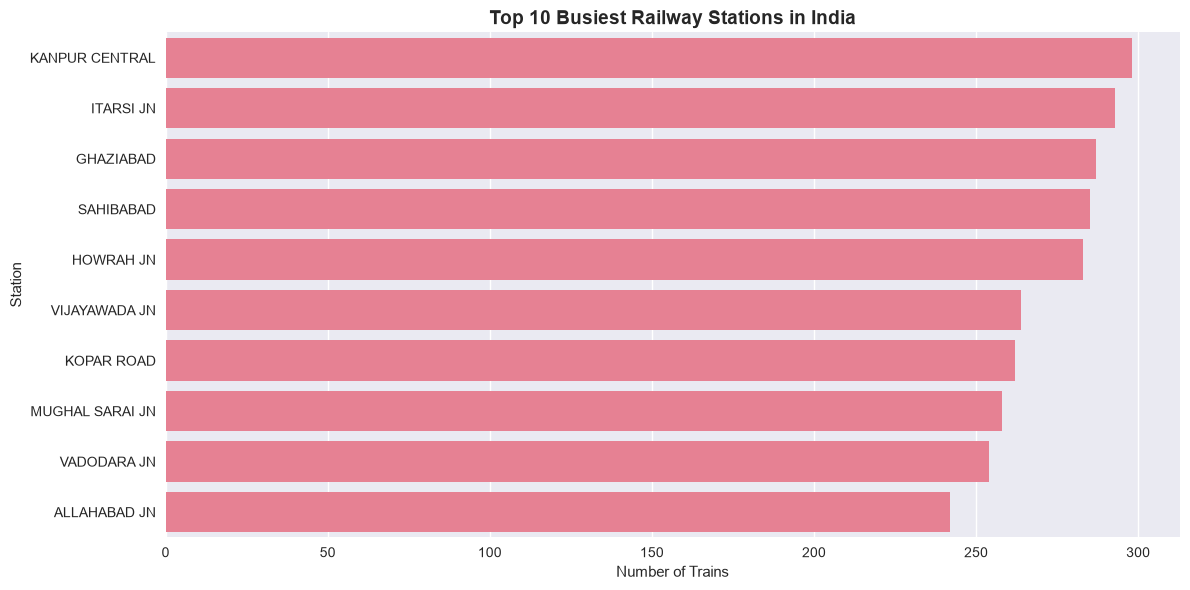


Top 10 Busiest Stations:
   station_name  total_trains
 KANPUR CENTRAL           298
      ITARSI JN           293
      GHAZIABAD           287
      SAHIBABAD           285
      HOWRAH JN           283
  VIJAYAWADA JN           264
     KOPAR ROAD           262
MUGHAL SARAI JN           258
    VADODARA JN           254
   ALLAHABAD JN           242


In [6]:
busiest_stations = df.groupby('station_name')['train_number'].nunique().reset_index()
busiest_stations.columns = ['station_name', 'total_trains']
busiest_stations = busiest_stations.sort_values(
    'total_trains', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=busiest_stations, x='total_trains', y='station_name')
plt.title('Top 10 Busiest Railway Stations in India', fontsize=14, fontweight='bold')
plt.xlabel('Number of Trains')
plt.ylabel('Station')
plt.tight_layout()
plt.savefig('busiest_stations.png', dpi=150)
plt.show()

print("\nTop 10 Busiest Stations:")
print(busiest_stations.to_string(index=False))

## 2. Longest routes

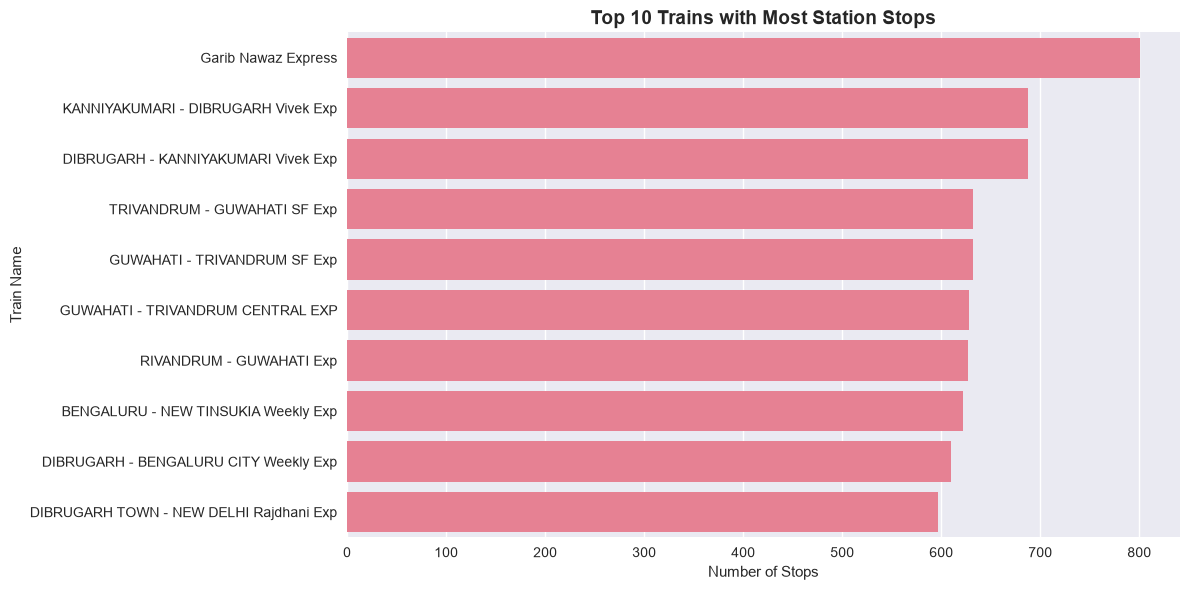


Top 10 Longest Routes:
                             train_name  total_stops
                    Garib Nawaz Express          801
    KANNIYAKUMARI - DIBRUGARH Vivek Exp          688
    DIBRUGARH - KANNIYAKUMARI Vivek Exp          688
           TRIVANDRUM - GUWAHATI SF Exp          632
           GUWAHATI - TRIVANDRUM SF Exp          632
      GUWAHATI - TRIVANDRUM CENTRAL EXP          628
               RIVANDRUM - GUWAHATI Exp          627
    BENGALURU - NEW TINSUKIA Weekly Exp          622
  DIBRUGARH - BENGALURU CITY Weekly Exp          610
DIBRUGARH TOWN - NEW DELHI Rajdhani Exp          597


In [7]:
longest_routes = df.groupby('train_name')['station_name'].nunique().reset_index()
longest_routes.columns = ['train_name', 'total_stops']
longest_routes = longest_routes.sort_values(
    'total_stops', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=longest_routes, x='total_stops', y='train_name')
plt.title('Top 10 Trains with Most Station Stops', fontsize=14, fontweight='bold')
plt.xlabel('Number of Stops')
plt.ylabel('Train Name')
plt.tight_layout()
plt.savefig('longest_routes.png', dpi=150)
plt.show()

print("\nTop 10 Longest Routes:")
print(longest_routes.to_string(index=False))

## 3. Train types

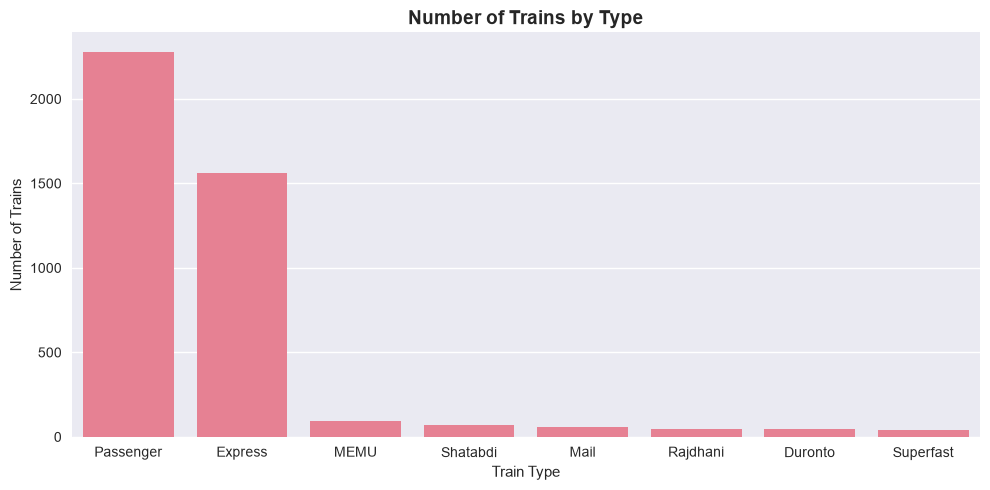


Train Type Distribution:
     Type  Count
Passenger   2279
  Express   1563
     MEMU     91
 Shatabdi     70
     Mail     60
 Rajdhani     48
  Duronto     48
Superfast     43


In [8]:
train_types = {
    'Express': df[df['train_name'].str.contains(
        'Express', case=False, na=False)]['train_number'].nunique(),
    'Passenger': df[df['train_name'].str.contains(
        'Passenger', case=False, na=False)]['train_number'].nunique(),
    'Mail': df[df['train_name'].str.contains(
        'Mail', case=False, na=False)]['train_number'].nunique(),
    'MEMU': df[df['train_name'].str.contains(
        'MEMU', case=False, na=False)]['train_number'].nunique(),
    'Superfast': df[df['train_name'].str.contains(
        'Superfast', case=False, na=False)]['train_number'].nunique(),
    'Rajdhani': df[df['train_name'].str.contains(
        'Rajdhani', case=False, na=False)]['train_number'].nunique(),
    'Shatabdi': df[df['train_name'].str.contains(
        'Shatabdi', case=False, na=False)]['train_number'].nunique(),
    'Duronto': df[df['train_name'].str.contains(
        'Duronto', case=False, na=False)]['train_number'].nunique(),
}

train_type_df = pd.DataFrame(
    list(train_types.items()), columns=['Type', 'Count'])
train_type_df = train_type_df.sort_values('Count', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=train_type_df, x='Type', y='Count')
plt.title('Number of Trains by Type', fontsize=14, fontweight='bold')
plt.xlabel('Train Type')
plt.ylabel('Number of Trains')
plt.tight_layout()
plt.savefig('train_types.png', dpi=150)
plt.show()

print("\nTrain Type Distribution:")
print(train_type_df.to_string(index=False))

## 4. Premium trains

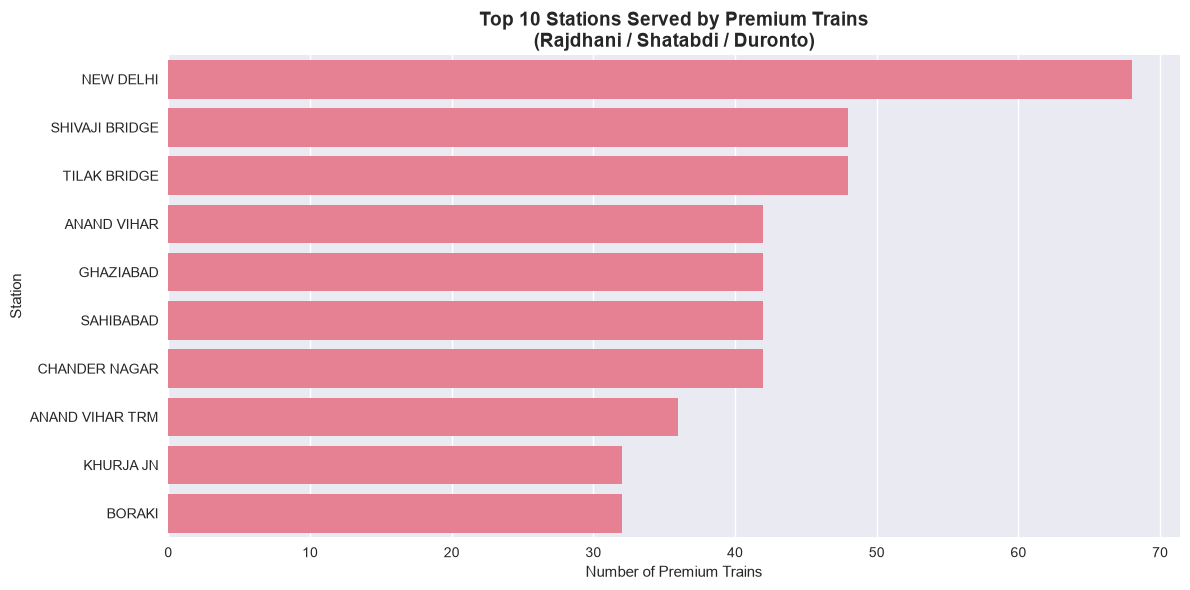


Top Stations for Premium Trains:
   station_name  premium_trains
      NEW DELHI              68
 SHIVAJI BRIDGE              48
   TILAK BRIDGE              48
    ANAND VIHAR              42
      GHAZIABAD              42
      SAHIBABAD              42
  CHANDER NAGAR              42
ANAND VIHAR TRM              36
      KHURJA JN              32
         BORAKI              32


In [9]:
premium = df[df['train_name'].str.contains(
    'Rajdhani|Shatabdi|Duronto', case=False, na=False)]

premium_stations = premium.groupby(
    'station_name')['train_number'].nunique().reset_index()
premium_stations.columns = ['station_name', 'premium_trains']
premium_stations = premium_stations.sort_values(
    'premium_trains', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=premium_stations, x='premium_trains', y='station_name')
plt.title('Top 10 Stations Served by Premium Trains\n(Rajdhani / Shatabdi / Duronto)',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Premium Trains')
plt.ylabel('Station')
plt.tight_layout()
plt.savefig('premium_trains.png', dpi=150)
plt.show()

print("\nTop Stations for Premium Trains:")
print(premium_stations.to_string(index=False))

## 5. Multiday journeys

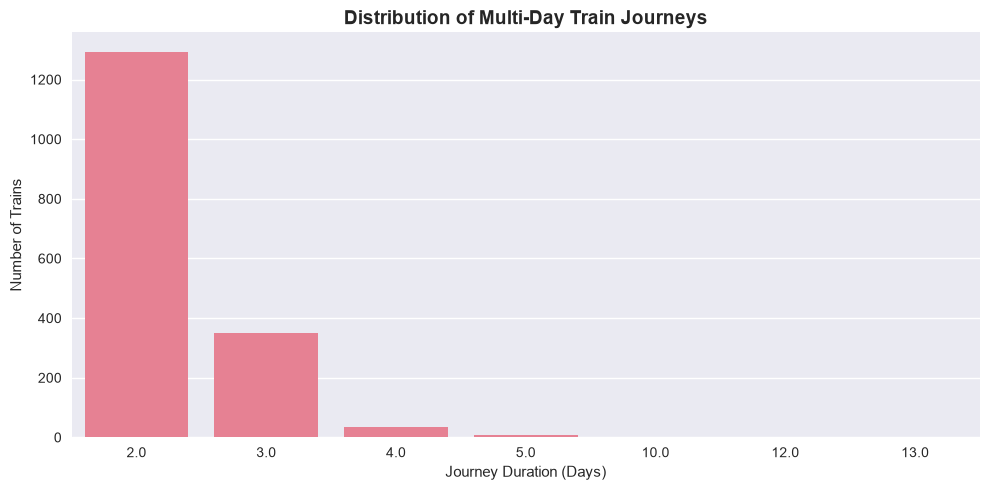


Trains running more than 1 day: 1,688
Longest journey: 13 days

Longest running trains:
                         train_name  max_day
         Lumding Guwahati Passenger     13.0
           Katwa Azimganj Passenger     12.0
  Velachery Chennai Beach Passenger     12.0
         Katihar Siliguri Passenger     10.0
DIBRUGARH - KANNIYAKUMARI Vivek Exp      5.0


In [10]:
# Trains that run for more than 1 day
multi_day = df.groupby('train_name')['day'].max().reset_index()
multi_day.columns = ['train_name', 'max_day']
multi_day = multi_day[multi_day['max_day'] > 1]

day_counts = multi_day['max_day'].value_counts().reset_index()
day_counts.columns = ['journey_days', 'number_of_trains']
day_counts = day_counts.sort_values('journey_days')

plt.figure(figsize=(10, 5))
sns.barplot(data=day_counts, x='journey_days', y='number_of_trains')
plt.title('Distribution of Multi-Day Train Journeys', fontsize=14, fontweight='bold')
plt.xlabel('Journey Duration (Days)')
plt.ylabel('Number of Trains')
plt.tight_layout()
plt.savefig('multi_day_journeys.png', dpi=150)
plt.show()

print(f"\nTrains running more than 1 day: {len(multi_day):,}")
print(f"Longest journey: {int(multi_day['max_day'].max())} days")
print(f"\nLongest running trains:")
print(multi_day.sort_values('max_day', ascending=False).head(5).to_string(index=False))

## Key Insights Summary

In [11]:
print("=" * 55)
print("   INDIAN RAILWAYS ANALYSIS — KEY INSIGHTS")
print("=" * 55)

print(f"""
DATASET
→ {len(df):,} schedule records across {df['train_number'].nunique():,} trains
→ {df['station_name'].nunique():,} unique stations covered

BUSIEST STATION
→ {busiest_stations.iloc[0]['station_name']}
→ {busiest_stations.iloc[0]['total_trains']} trains stop here daily

LONGEST ROUTE
→ {longest_routes.iloc[0]['train_name']}
→ {longest_routes.iloc[0]['total_stops']} station stops

MOST COMMON TRAIN TYPE
→ {train_type_df.iloc[0]['Type']} trains — {train_type_df.iloc[0]['Count']} total

PREMIUM NETWORK
→ {premium_stations.iloc[0]['station_name']} is the top premium hub
→ {premium_stations.iloc[0]['premium_trains']} Rajdhani/Shatabdi/Duronto trains

MULTI-DAY JOURNEYS
→ {len(multi_day):,} trains run for more than 1 day
→ Longest journey: {int(multi_day['max_day'].max())} days
""")

   INDIAN RAILWAYS ANALYSIS — KEY INSIGHTS

DATASET
→ 417,080 schedule records across 5,208 trains
→ 8,495 unique stations covered

BUSIEST STATION
→ KANPUR CENTRAL
→ 298 trains stop here daily

LONGEST ROUTE
→ Garib Nawaz Express
→ 801 station stops

MOST COMMON TRAIN TYPE
→ Passenger trains — 2279 total

PREMIUM NETWORK
→ NEW DELHI is the top premium hub
→ 68 Rajdhani/Shatabdi/Duronto trains

MULTI-DAY JOURNEYS
→ 1,688 trains run for more than 1 day
→ Longest journey: 13 days

